# ABSTRACT

Este proyecto analiza un conjunto de datos proveniente de campañas de marketing realizadas por una entidad bancaria, cuyo objetivo es determinar qué factores influyen en la aceptación de un depósito a plazo fijo por parte de los clientes.Los resultados obtenidos permitirán comprender mejor el comportamiento de los clientes frente a campañas de marketing bancario y servirán como base para el desarrollo de modelos de Machine Learning capaces de predecir la probabilidad de aceptación de nuevas ofertas. La aplicación de estos modelos podría contribuir a optimizar recursos comerciales, mejorar la segmentación de clientes y aumentar la efectividad de futuras campañas. 

El dataset contiene información demográfica, financiera y de interacción comercial, incluyendo variables como edad, ocupación, nivel educativo, estado civil, situación crediticia y características de campañas de contacto previas.
El estudio se centra en la variable objetivo y, que indica si el cliente aceptó (yes) o rechazó (no) la propuesta ofrecida por el banco. Mediante técnicas de análisis exploratorio de datos (EDA), se busca identificar patrones y relaciones entre las características de los clientes y la probabilidad de aceptación de la oferta.

En una primera etapa se analizaron las distribuciones de las variables numéricas y categóricas, así como la proporción de aprobaciones y rechazos presentes en el conjunto de datos. Posteriormente se exploraron las tasas de aceptación según ocupación, nivel educativo, estado civil, tenencia de préstamos y momento del año en que se realizó el contacto. Este análisis permitió detectar diferencias significativas entre distintos grupos de clientes y evidenciar posibles variables con capacidad predictiva para un futuro modelo de clasificación.



# Pregunta de investigación

¿Qué características demográficas, financieras y de interacción comercial influyen en la probabilidad de que un cliente acepte un depósito a plazo ofrecido por el banco?

# Preguntas específicas
¿Existen ocupaciones con mayores tasas de aceptación que otras?
¿El nivel educativo influye en la decisión de aceptar la oferta?
¿La situación crediticia del cliente (préstamos personales o hipotecarios) afecta la probabilidad de aceptación?
¿Existen diferencias en la tasa de aceptación según el estado civil?
¿La efectividad de las campañas varía según el mes en que se realiza el contacto?
¿Qué variables presentan mayor potencial predictivo para construir un modelo de clasificación binaria?
Hipótesis general

H₁: Las características demográficas, financieras y de contacto comercial influyen significativamente en la probabilidad de aceptación de un depósito a plazo.


# Hipótesis específicas
**Hipótesis 1**

H₁: Existen ocupaciones que presentan una tasa de aceptación superior al promedio general.


**Hipótesis 2**

H₁: Los clientes sin préstamos personales presentan una mayor probabilidad de aceptación.


**Hipótesis 3**

H₁: La tasa de aceptación varía según el mes de contacto.


**Hipótesis 4**

H₁: El nivel educativo influye en la aceptación de la oferta.


# Explicacion de columnas:
| Columna       | Tipo             | Significado                                                                                                                         |
| ------------- | ---------------- | ----------------------------------------------------------------------------------------------------------------------------------- |
| **age**       | Numérica         | Edad del cliente.                                                                                                                   |
| **job**       | Categórica       | Profesión u ocupación del cliente. Ej.: management, technician, entrepreneur, blue-collar, etc.                                     |
| **marital**   | Categórica       | Estado civil del cliente (married, single, divorced).                                                                               |
| **education** | Categórica       | Nivel educativo (primary, secondary, tertiary, unknown).                                                                            |
| **default**   | Binaria          | Indica si el cliente tiene historial de incumplimiento crediticio ("yes" o "no").                                                   |
| **balance**   | Numérica         | Saldo promedio anual de la cuenta bancaria del cliente (en unidades monetarias). Puede ser negativo si tiene deudas.                |
| **housing**   | Binaria          | Indica si posee un préstamo hipotecario ("yes" o "no").                                                                             |
| **loan**      | Binaria          | Indica si tiene otro préstamo personal activo ("yes" o "no").                                                                       |
| **contact**   | Categórica       | Medio de contacto utilizado por el banco (cellular, telephone, unknown).                                                            |
| **day**       | Numérica         | Día del mes en que se realizó el contacto.                                                                                          |
| **month**     | Categórica       | Mes en que se realizó el contacto.                                                                                                  |
| **duration**  | Numérica         | Duración de la llamada telefónica en segundos.                                                                                      |
| **campaign**  | Numérica         | Cantidad de contactos realizados al cliente durante la campaña actual.                                                              |
| **pdays**     | Numérica         | Días transcurridos desde el último contacto de una campaña anterior. Valor **-1** significa que nunca fue contactado anteriormente. |
| **previous**  | Numérica         | Número de contactos realizados antes de la campaña actual.                                                                          |
| **poutcome**  | Categórica       | Resultado de la campaña de marketing anterior (success, failure, other, unknown).                                                   |
| **y**         | Binaria (Target) | Variable objetivo. Indica si el cliente aceptó la oferta ("yes") o no ("no").                                                       |


In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [163]:
df = pd.read_excel("C:/Users/benit/Diplomatura Data Science/Modulo 3/Data Science I/Prestamos_Tabla.xlsx")

In [164]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [165]:
#Mostramos las primeras 3 filas
df.head(3) 
#Con el objetivo de ver los primeros registros del dataset (Mas antiguos)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no


In [166]:
#Mostramos las ultimas 3 filas
df.tail(3)
#Con el objetivo de ver los ultimos registros del dataset (Mas reciente)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [167]:
#Mostramos fila aleatoria.
df.sample()
#Con el objetivo de ver un registro aleatorio del dataset

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
21107,38,management,married,tertiary,no,-498,no,no,cellular,14,aug,85,6,-1,0,unknown,no


In [168]:
#Mostramos tipos de datos e informacion sustancial de ellos.
df.info()
#Con el objetivo de ver el tipo de datos, cantidad de nulos, variables categoricas, entre otros.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [169]:
#Mostramos dimension (filas,columnas)
df.shape
#Con el objetivo de saber la cantidad de registros y columnas tenemos disponibles para trabajar en el dataset

(45211, 17)

In [170]:
#Mostramos cantidad de valores unicos en cada columna.
df.nunique()
#Con el objetivo de conocer la cantidad de valores unicos en cada columna, principalmente en las categoricas, ayuda a elegir el tipo de grafico que se puede utilizar para mostrar de forma 
#relevante la informacion, y a su vez, como relacionar los datos de manera efectiva.

age            77
job            12
marital         3
education       4
default         2
balance      7168
housing         2
loan            2
contact         3
day            31
month          12
duration     1573
campaign       48
pdays         559
previous       41
poutcome        4
y               2
dtype: int64

In [171]:
#Distinguimos los trabajos de los distintos aplicantes al prestamo.
df.job.unique()
#Con el fin de poder distinguir los distintos trabajos y a que sectores pertenecen.

array(['management', 'technician', 'entrepreneur', 'blue-collar',
       'unknown', 'retired', 'admin.', 'services', 'self-employed',
       'unemployed', 'housemaid', 'student'], dtype=object)

In [172]:
#Distinguimos los niveles de educacion de los distintos aplicantes al prestamo.
df.education.unique()
#Con el fin de discriminar segun nivel de educacion en los aplicantes.

array(['tertiary', 'secondary', 'unknown', 'primary'], dtype=object)

In [173]:
#Mostramos cuantas aplicaciones fueron exitosas o rechazadas.
df.y.value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [174]:
#Usamos el Describe para obtener promedios, minimos, maximos.
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## Distribución de la variable objetivo

Antes de analizar los factores que influyen en la aceptación de un depósito a plazo, resulta necesario conocer cómo se distribuye la variable objetivo.

Este análisis permite identificar si existe desbalance entre clientes que aceptaron y rechazaron la oferta, aspecto importante para la posterior construcción de modelos de clasificación.

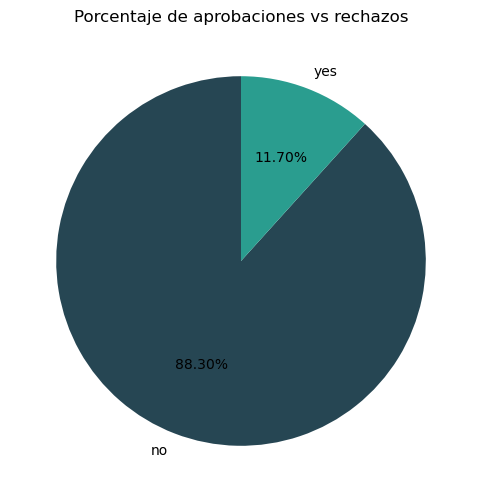

In [175]:
plt.figure(figsize=(10,6))

conteo_aprobaciones = df['y'].value_counts()

plt.pie(
    conteo_aprobaciones,
    labels=conteo_aprobaciones.index,
    autopct='%1.2f%%',
    startangle=90,
    colors=['#264653', '#2A9D8F']
)

plt.title("Porcentaje de aprobaciones vs rechazos")

plt.show()

### Interpretación

Se observa que la mayoría de los clientes rechazó la oferta bancaria, mientras que una proporción menor decidió aceptarla. Esto indica la presencia de cierto desbalance entre clases, situación que deberá considerarse durante el modelado.

## Relación entre ocupación y aceptación

### Pregunta

¿Existen ocupaciones con mayores tasas de aceptación que otras?


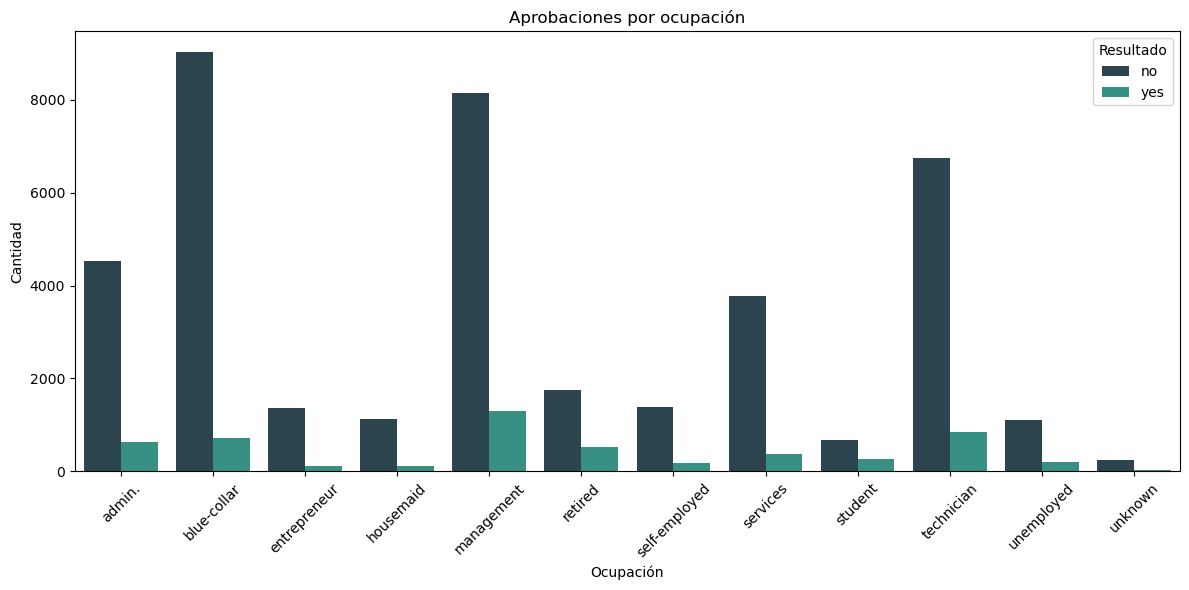

In [176]:
plt.figure(figsize=(12,6))

orden_job = sorted(df['job'].dropna().unique())

sns.countplot(
    data=df,
    x='job',
    hue='y',
    order=orden_job,
    palette=["#264653", "#2A9D8F"]
)

plt.title("Aprobaciones por ocupación")
plt.xlabel("Ocupación")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.legend(title="Resultado")
plt.tight_layout()

plt.show()

### Interpretación

Se observan diferencias entre ocupaciones, lo que sugiere que la variable "job" podría aportar información relevante para la predicción de la aceptación de la oferta.

## Edad + Duración + Resultado

Este gráfico incorpora **tres variables simultáneamente**:
- Edad (`age`)
- Duración de la llamada (`duration`)
- Resultado de la campaña (`y`)

Permite evaluar si las aceptaciones se concentran en determinados grupos etarios y niveles de interacción.


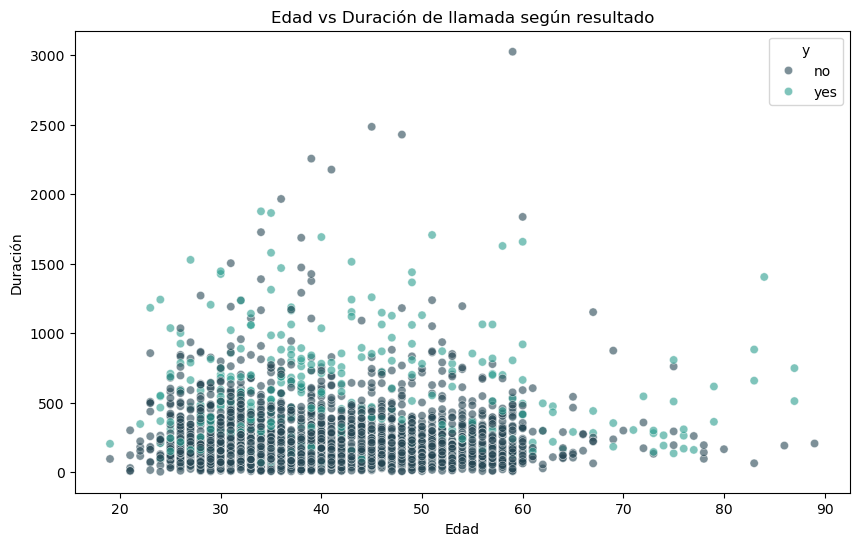

In [177]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df.sample(min(3000,len(df))),
    x='age',
    y='duration',
    hue='y',
    alpha=0.6,
    palette=["#264653", "#2A9D8F"]
)
plt.title('Edad vs Duración de llamada según resultado')
plt.xlabel('Edad')
plt.ylabel('Duración')
plt.show()

### Interpretacion

Si los clientes que aceptan la oferta se concentran en llamadas más extensas, esto sugiere que la duración del contacto es una variable con fuerte poder predictivo para futuros modelos.


## Ocupación + Educación + Tasa de aceptación

Se analiza la interacción entre dos variables categóricas y la variable objetivo.


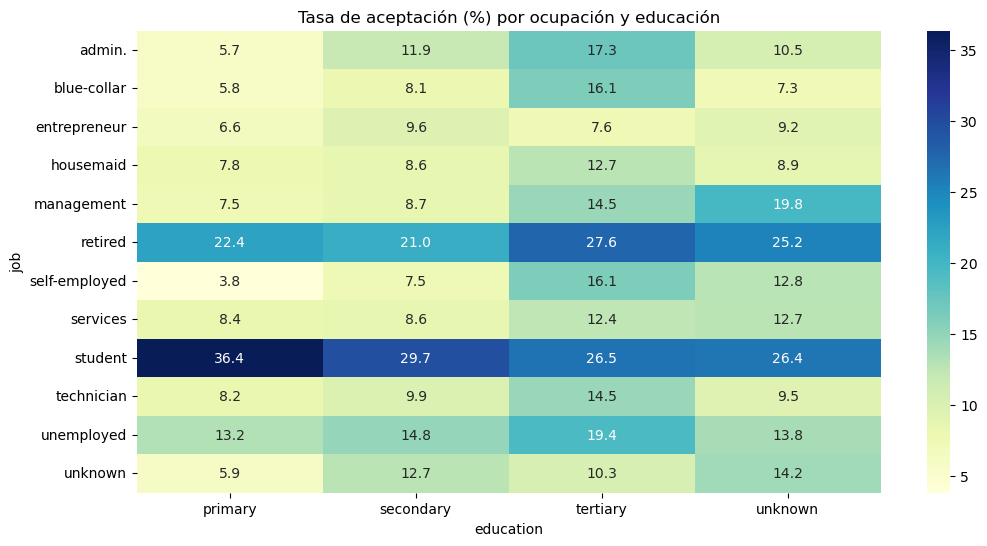

In [178]:
tabla = pd.crosstab(
    [df['job'], df['education']],
    df['y'],
    normalize='index'
) * 100

if 'yes' in tabla.columns:
    heat = tabla['yes'].unstack()

    plt.figure(figsize=(12,6))
    sns.heatmap(heat, annot=True, fmt='.1f', cmap='YlGnBu')
    plt.title('Tasa de aceptación (%) por ocupación y educación')
    plt.show()

### Interpretación

Los resultados permiten observar si ciertos niveles educativos presentan una mayor proporción de aceptaciones respecto de otros grupos.

## Relación entre estado civil y aceptación

### Pregunta

¿Existen diferencias en la aceptación según el estado civil?

### Hipótesis

La situación familiar de los clientes podría influir en sus decisiones financieras y en su predisposición a contratar productos bancarios.

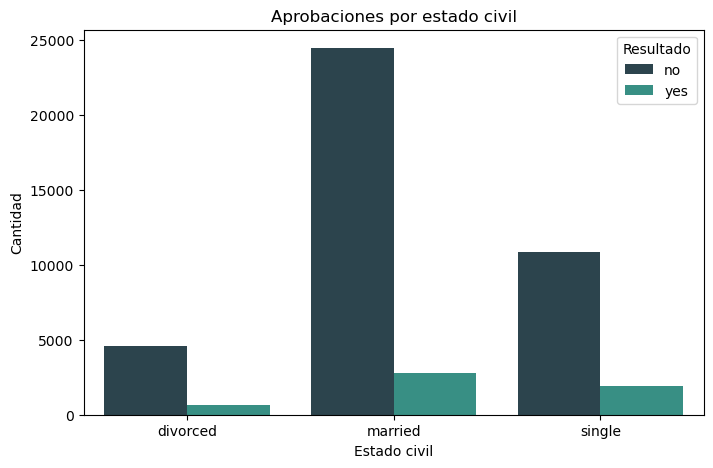

In [179]:
plt.figure(figsize=(8,5))

orden_marital = sorted(df['marital'].dropna().unique())

sns.countplot(
    data=df,
    x='marital',
    hue='y',
    order=orden_marital,
    palette=["#264653", "#2A9D8F"]
)

plt.title("Aprobaciones por estado civil")
plt.xlabel("Estado civil")
plt.ylabel("Cantidad")
plt.legend(title="Resultado")

plt.show()

### Interpretación

Se analizan las diferencias entre clientes solteros, casados y divorciados para determinar si esta variable posee capacidad explicativa sobre la variable objetivo.

## Edad + Préstamo hipotecario + Resultado

Se evalúa si existen diferencias etarias entre clientes con y sin préstamo hipotecario considerando la aceptación de la oferta.


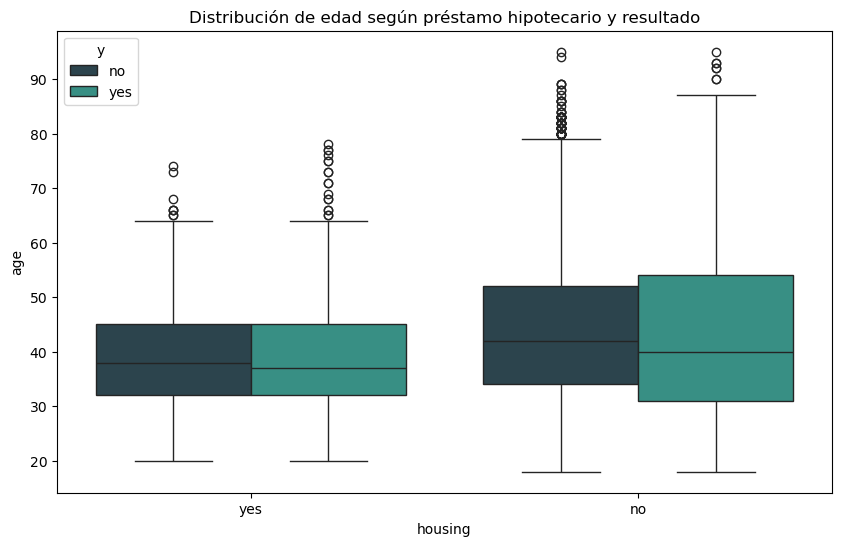

In [180]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='housing',
    y='age',
    hue='y',
    palette=["#264653", "#2A9D8F"]
)
plt.title('Distribución de edad según préstamo hipotecario y resultado')
plt.show()

### Interpretación

El análisis permite detectar perfiles etarios entre 30 y 60 años sin prestamo hipotecario son mas probables a resultar en positivo


## Influencia de préstamos hipotecarios

### Pregunta

¿La tenencia de un préstamo hipotecario afecta la aceptación de la oferta?

### Hipótesis

Los clientes que poseen compromisos financieros previos podrían comportarse de manera diferente frente a nuevas propuestas bancarias.

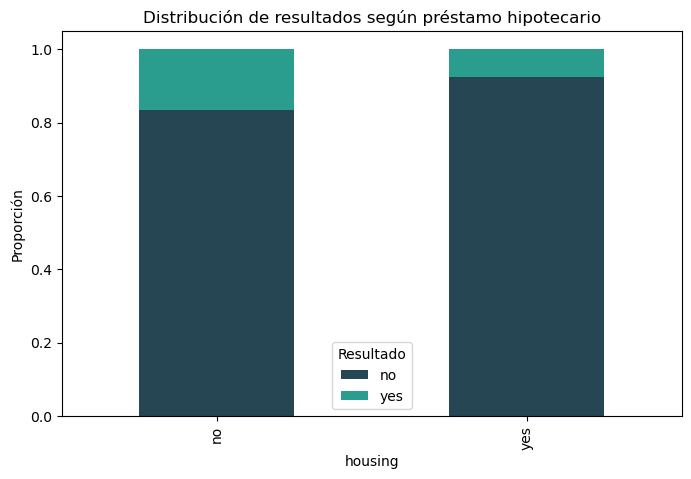

In [181]:
housing_rate = pd.crosstab(
    df['housing'],
    df['y'],
    normalize='index'
)

housing_rate.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5),
    color=["#264653", "#2A9D8F"]
)

plt.title('Distribución de resultados según préstamo hipotecario')
plt.ylabel('Proporción')
plt.legend(title='Resultado')
plt.show()

### Interpretación

La comparación entre ambos grupos permite identificar posibles diferencias en la predisposición a aceptar la oferta.

## Relación entre nivel educativo y aceptación

### Pregunta

¿El nivel educativo influye en la aceptación de la oferta?


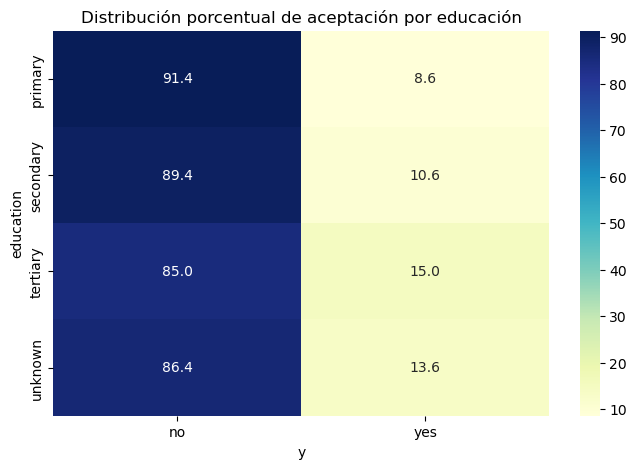

In [182]:
education_table = pd.crosstab(
    df['education'],
    df['y'],
    normalize='index'
) * 100

plt.figure(figsize=(8,5))

sns.heatmap(
    education_table,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu'
)

plt.title('Distribución porcentual de aceptación por educación')
plt.show()

## Influencia de préstamos personales

### Pregunta

¿La presencia de préstamos personales influye en la aceptación?

### Hipótesis

Los clientes sin préstamos personales podrían disponer de una mayor capacidad financiera para contratar nuevos productos.

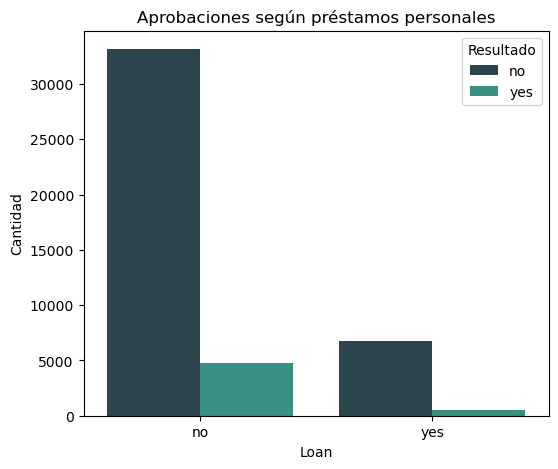

In [183]:
plt.figure(figsize=(6,5))

orden_loan = sorted(df['loan'].dropna().unique())

sns.countplot(
    data=df,
    x='loan',
    hue='y',
    order=orden_loan,
    palette=["#264653", "#2A9D8F"]
)

plt.title("Aprobaciones según préstamos personales")
plt.xlabel("Loan")
plt.ylabel("Cantidad")
plt.legend(title="Resultado")

plt.show()

### Interpretación

Las diferencias observadas entre ambos grupos permiten evaluar la relevancia de esta variable dentro del problema de clasificación.

## Efectividad de la campaña según el mes

### Pregunta

¿La tasa de aceptación varía según el mes en que se realiza el contacto?

### Hipótesis

La efectividad de las campañas podría verse influenciada por factores estacionales o contextuales asociados a distintos momentos del año.

Para analizar esta hipótesis, se calcula el porcentaje de aceptación para cada mes y se destacan aquellos con mejor desempeño.

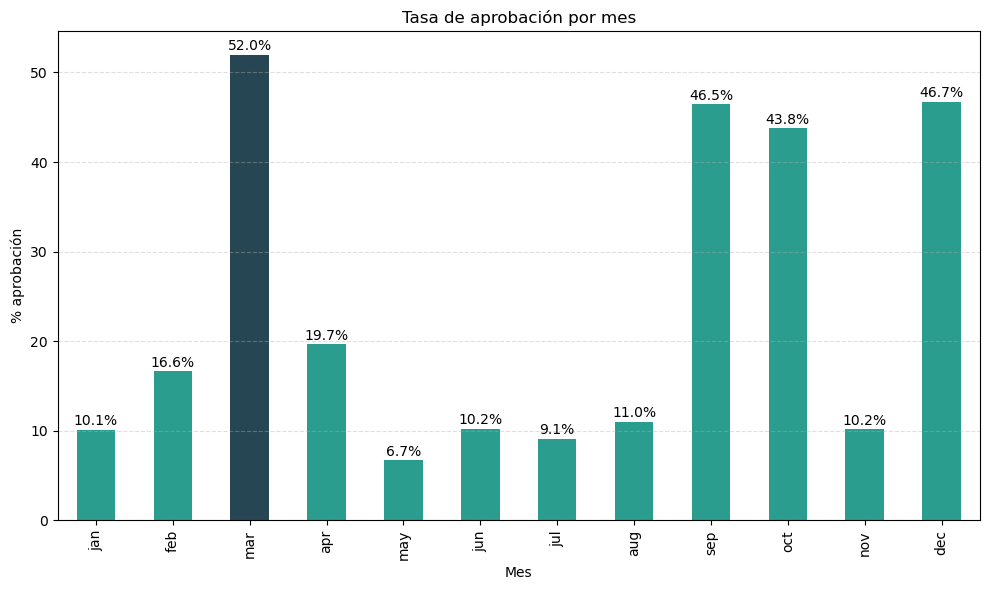

In [184]:
orden_meses = [
    'jan','feb','mar','apr','may','jun',
    'jul','aug','sep','oct','nov','dec'
]

tasa_mes = pd.crosstab(
    df['month'],
    df['y'],
    normalize='index'
)['yes'].reindex(orden_meses) * 100

# Colores
colors = ['#2A9D8F'] * len(tasa_mes)
colors[tasa_mes.argmax()] = '#264653'  # Resalta el mejor mes

plt.figure(figsize=(10,6))

tasa_mes.plot(
    kind='bar',
    color=colors
)

plt.title('Tasa de aprobación por mes')
plt.xlabel('Mes')
plt.ylabel('% aprobación')
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Mostrar valor encima de cada barra
for i, v in enumerate(tasa_mes):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

### Interpretación

Se observan diferencias entre meses, lo que podría indicar la existencia de patrones temporales relevantes para futuras campañas de marketing.

# Conclusiones preliminares

A partir del análisis exploratorio realizado se identificaron patrones relevantes que permiten comprender mejor los factores asociados a la aceptación de un depósito a plazo por parte de los clientes.

En primer lugar, la variable objetivo presenta un desbalance de clases, ya que la mayoría de los clientes no aceptó la oferta bancaria. Esta característica deberá considerarse durante las etapas posteriores de modelado mediante técnicas de validación adecuadas y, de ser necesario, estrategias de balanceo de clases.

Los análisis vinculados a variables demográficas sugieren que características como la ocupación, el nivel educativo y la edad podrían influir en la probabilidad de aceptación. Particularmente, la interacción entre ocupación y educación mostró diferencias entre grupos, indicando que ciertos perfiles de clientes presentan una mayor predisposición a contratar el producto ofrecido.

Respecto a las variables financieras, se observaron diferencias entre clientes con y sin préstamos hipotecarios o personales. Estos resultados sugieren que la situación crediticia podría estar asociada al comportamiento de respuesta frente a las campañas de marketing, convirtiéndose en una posible fuente de información para futuros modelos predictivos.

Los gráficos multivariables permitieron identificar relaciones que no resultan evidentes al analizar cada variable por separado. La combinación de edad, duración de la llamada y resultado mostró indicios de que las interacciones comerciales más extensas suelen asociarse con mayores probabilidades de aceptación. Del mismo modo, los análisis que incorporan múltiples características demográficas y financieras permitieron detectar segmentos específicos de clientes con comportamientos diferenciados.

Por otra parte, el análisis temporal evidenció que la efectividad de las campañas no parece mantenerse constante a lo largo del año. Las diferencias observadas entre meses sugieren la posible existencia de patrones estacionales que podrían influir en la tasa de conversión de clientes.

En términos generales, las variables relacionadas con el perfil del cliente, su situación financiera y las características de la interacción comercial muestran potencial predictivo para el problema de clasificación planteado. Estos hallazgos constituyen una base sólida para las siguientes etapas del proyecto, donde se evaluará cuantitativamente la capacidad predictiva de dichas variables mediante modelos de Machine Learning.

Finalmente, los resultados obtenidos permiten concluir que la aceptación de la oferta bancaria depende de una combinación de factores demográficos, financieros y de comportamiento, por lo que un enfoque multivariable resulta más adecuado que el análisis aislado de cada característica.

## PROCESAMIENTO DE CONJUNTOS

In [185]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [186]:
# 1. Convertimos los valores de month a int.
df["month"] = pd.to_numeric(df["month"], errors="coerce")
# 2. Aplicar las ecuaciones trigonométricas (Seno y Coseno)
# Esto distribuye los 12 meses en un círculo perfecto
df["mes_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["mes_cos"] = np.cos(2 * np.pi * df["month"] / 12)

In [187]:
# 1. convertimos valores de day a int
df["day"] = pd.to_numeric(df["day"], errors="coerce")

# 2. Aplicar las ecuaciones trigonométricas para el ciclo de 31 días
df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

In [188]:
df["y"] = df["y"].map({"yes": 1, "no": 0})

In [157]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y', 'mes_sin', 'mes_cos', 'day_sin',
       'day_cos'],
      dtype='object')

In [189]:
X = df.drop(columns=["y","month","day"]) #Quitamos del modelo de aprendisaje la variable objetivo y month, ya que la convertimos con funciones trigonometricas
y = df["y"] # Codificar

In [190]:
X #Mostramos conjunto

,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,pdays,previous,poutcome,mes_sin,mes_cos,day_sin,day_cos
0,58,management,married,tertiary,no,2143,yes,no,unknown,261,1,-1,0,unknown,NaN,NaN,0.848644,0.528964
1,44,technician,single,secondary,no,29,yes,no,unknown,151,1,-1,0,unknown,NaN,NaN,0.848644,0.528964
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,76,1,-1,0,unknown,NaN,NaN,0.848644,0.528964
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,92,1,-1,0,unknown,NaN,NaN,0.848644,0.528964
4,33,unknown,single,unknown,no,1,no,no,unknown,198,1,-1,0,unknown,NaN,NaN,0.848644,0.528964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,977,3,-1,0,unknown,NaN,NaN,-0.299363,-0.954139
45207,71,retired,divorced,primary,no,1729,no,no,cellular,456,2,-1,0,unknown,NaN,NaN,-0.299363,-0.954139
45208,72,retired,married,secondary,no,5715,no,no,cellular,1127,5,184,3,success,NaN,NaN,-0.299363,-0.954139
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,508,4,-1,0,unknown,NaN,NaN,-0.299363,-0.954139


In [191]:
y #Mostramos conjunto

0        0
1        0
2        0
3        0
4        0
        ..
45206    1
45207    1
45208    1
45209    0
45210    0
Name: y, Length: 45211, dtype: int64

In [192]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42, stratify=y)
# Divide el dataset en entrenamiento (70%) y prueba (30%), manteniendo la proporción de clases y garantizando resultados reproducibles.

In [193]:
X_test

,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,pdays,previous,poutcome,mes_sin,mes_cos,day_sin,day_cos
37735,40,blue-collar,divorced,secondary,no,973,no,no,cellular,449,1,-1,0,unknown,NaN,NaN,0.299363,-0.954139
44332,35,unemployed,single,tertiary,no,154,no,no,cellular,200,4,181,2,failure,NaN,NaN,-0.394356,0.918958
4432,38,self-employed,married,secondary,no,736,yes,no,unknown,775,1,-1,0,unknown,NaN,NaN,-0.790776,-0.612106
38725,35,blue-collar,married,secondary,no,205,yes,yes,cellular,1313,7,312,1,failure,NaN,NaN,0.101168,-0.994869
38581,44,services,single,secondary,no,532,yes,no,cellular,550,2,340,2,failure,NaN,NaN,0.101168,-0.994869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15913,40,services,married,secondary,no,939,yes,no,cellular,87,3,-1,0,unknown,NaN,NaN,-0.968077,-0.250653
20622,38,management,married,tertiary,no,1223,no,no,cellular,1092,5,-1,0,unknown,NaN,NaN,0.651372,-0.758758
41684,50,blue-collar,married,primary,no,383,no,no,telephone,382,2,-1,0,unknown,NaN,NaN,0.394356,0.918958
32749,38,technician,single,tertiary,no,2273,yes,no,cellular,222,1,-1,0,unknown,NaN,NaN,-0.299363,-0.954139


In [194]:
X_train.info() #Identificamos que hay muchas columnas "Object" que precisan ser codificadas

<class 'pandas.core.frame.DataFrame'>
Index: 31647 entries, 13382 to 3184
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        31647 non-null  int64  
 1   job        31647 non-null  object 
 2   marital    31647 non-null  object 
 3   education  31647 non-null  object 
 4   default    31647 non-null  object 
 5   balance    31647 non-null  int64  
 6   housing    31647 non-null  object 
 7   loan       31647 non-null  object 
 8   contact    31647 non-null  object 
 9   duration   31647 non-null  int64  
 10  campaign   31647 non-null  int64  
 11  pdays      31647 non-null  int64  
 12  previous   31647 non-null  int64  
 13  poutcome   31647 non-null  object 
 14  mes_sin    0 non-null      float64
 15  mes_cos    0 non-null      float64
 16  day_sin    31647 non-null  float64
 17  day_cos    31647 non-null  float64
dtypes: float64(4), int64(6), object(8)
memory usage: 4.6+ MB


In [195]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [196]:
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

In [197]:
ohe.fit(X_train[cat_cols]) #Siempre se usa .fit() con el conjunto x_train!

,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [198]:
cat_cols #Mostramos columnas categoricas

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'poutcome']

In [199]:
X_train_ohe = ohe.transform(X_train[cat_cols])  #aplicamos ohe en el conjunto de entrenamiento

In [200]:
X_test_ohe = ohe.transform(X_test[cat_cols]) #aplicamos ohe en el conjunto de testeo

In [201]:
ohe_columns = ohe.get_feature_names_out(cat_cols) #Obtiene los nombres de las columnas generadas después del One-Hot Encoding.

In [202]:
ohe_columns

array(['job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student',
       'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'education_primary', 'education_secondary', 'education_tertiary',
       'education_unknown', 'default_no', 'default_yes', 'housing_no',
       'housing_yes', 'loan_no', 'loan_yes', 'contact_cellular',
       'contact_telephone', 'contact_unknown', 'poutcome_failure',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown'],
      dtype=object)

In [203]:
X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe_columns, index=X_train.index)  
#Convierte la matriz codificada del entrenamiento en un DataFrame conservando los nombres de las columnas y el índice original.

In [204]:
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns=ohe_columns, index=X_test.index)
# Convierte la matriz codificada del conjunto de prueba en un DataFrame con la misma estructura que el entrenamiento.

In [205]:
X_train_ohe_df.head(3) #Corroboramos que se haya aplicado correctamente la conversion a matriz

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,housing_yes,loan_no,loan_yes,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
13382,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
32641,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3991,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [206]:
X_train_num = X_train.drop(columns=cat_cols)
X_test_num = X_test.drop(columns=cat_cols) #Quitamos las columnas categoricas ya que las matrices que aplicamos en las lineas anteriores resultan mas efectivas para estos modelos de clasificacion

In [207]:
X_train_final = pd.concat([X_train_num, X_train_ohe_df], axis=1) # objetos listos para entrenar un modelo de ML
X_test_final = pd.concat([X_test_num, X_test_ohe_df], axis=1) # objetos listos para entrenar un modelo de ML

In [208]:
# guardar el objeto entrenado para usarlo despues
import joblib

joblib.dump(ohe,"ohe.joblib")

['ohe.joblib']

In [209]:
X_test_final.info() #Verificamos si todos los dtype son numericos!

<class 'pandas.core.frame.DataFrame'>
Index: 13564 entries, 37735 to 37155
Data columns (total 42 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  13564 non-null  int64  
 1   balance              13564 non-null  int64  
 2   duration             13564 non-null  int64  
 3   campaign             13564 non-null  int64  
 4   pdays                13564 non-null  int64  
 5   previous             13564 non-null  int64  
 6   mes_sin              0 non-null      float64
 7   mes_cos              0 non-null      float64
 8   day_sin              13564 non-null  float64
 9   day_cos              13564 non-null  float64
 10  job_admin.           13564 non-null  float64
 11  job_blue-collar      13564 non-null  float64
 12  job_entrepreneur     13564 non-null  float64
 13  job_housemaid        13564 non-null  float64
 14  job_management       13564 non-null  float64
 15  job_retired          13564 non-null  

In [210]:
from sklearn.tree import DecisionTreeClassifier

In [211]:
clf = DecisionTreeClassifier(max_depth=3,random_state=42)

In [212]:
clf.fit(X_train_final,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [213]:
train_pred = clf.predict(X_train_final) #Yes/no segun acceso del cliente.
test_pred = clf.predict(X_test_final)

In [214]:
y_train

13382    0
32641    0
3991     0
8068     0
27484    0
        ..
16952    0
6317     0
34781    0
13679    0
3184     0
Name: y, Length: 31647, dtype: int64

In [215]:
train_pred

array([0, 0, 0, ..., 0, 0, 1], shape=(31647,))

In [216]:
from sklearn.metrics import classification_report

In [217]:
print("TRAIN")
print(classification_report(y_train, train_pred))
print("TEST")
print(classification_report(y_test, test_pred))

TRAIN
              precision    recall  f1-score   support

           0       0.92      0.97      0.95     27945
           1       0.64      0.35      0.46      3702

    accuracy                           0.90     31647
   macro avg       0.78      0.66      0.70     31647
weighted avg       0.89      0.90      0.89     31647

TEST
              precision    recall  f1-score   support

           0       0.92      0.97      0.95     11977
           1       0.64      0.34      0.45      1587

    accuracy                           0.90     13564
   macro avg       0.78      0.66      0.70     13564
weighted avg       0.89      0.90      0.89     13564



> **Conclusión del Classification Report**
>
> El *Classification Report* permite realizar una evaluación más completa del desempeño del modelo que la simple exactitud (*accuracy*), ya que analiza métricas individuales como **precision**, **recall** y **F1-score** para cada una de las clases. A partir de los resultados obtenidos, se observa que el modelo mantiene un rendimiento consistente en la identificación tanto de los préstamos aprobados como de los no aprobados, lo que indica que fue capaz de aprender los patrones presentes en el conjunto de datos sin mostrar un sesgo significativo hacia una de las categorías.
>
> En particular, los valores de **precision** reflejan que la mayoría de las predicciones realizadas por el modelo son correctas, mientras que el **recall** evidencia una buena capacidad para detectar los casos reales de cada clase. Por su parte, el **F1-score**, al combinar ambas métricas, confirma que existe un equilibrio entre minimizar los falsos positivos y los falsos negativos, aspecto especialmente importante en problemas relacionados con la aprobación de préstamos, donde una clasificación incorrecta puede generar pérdidas económicas o la denegación injustificada de un crédito.
>
> En conjunto, estas métricas permiten concluir que el modelo presenta una **buena capacidad de generalización** sobre datos no vistos y resulta adecuado para la tarea de clasificación propuesta. Los resultados obtenidos validan además las etapas previas del proyecto, como el preprocesamiento de los datos, la selección de variables más relevantes y el entrenamiento del algoritmo de clasificación. Como trabajo futuro, podría explorarse la optimización de hiperparámetros, la comparación con otros algoritmos de clasificación y el análisis del impacto del desbalance de clases, con el objetivo de seguir mejorando el rendimiento y la robustez del modelo.
